In [ ]:
import seaborn as sns
import pandas as pd

df = sns.load_dataset("titanic")
df.to_csv("analytics/titanic.csv", index=False)

In [ ]:
#1
import seaborn as sns
import pandas as pd
import os

print("========df.shape=====")
print(df.shape)
print("\n======df.info()=====")
print(df.info())
print("\n======df.describe()======")
print(df.describe())
print("\n======percentage of missing values ======")
print(df.isnull().sum()/len(df)*100)
os.makedirs("analytics",exist_ok=True)
df.to_csv("analytics/titanic.csv",index=False)
print("Created analytics/titanic.csv -DONE")
print(pd.read_csv("analytics/titanic.csv").shape)

========df.shape=====
(891, 15)

======df.info()=====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

======df.describe()

In [ ]:
#2
print("Threshold Rule: <5% drop rows, 5-30% impute, >30% drop column")
print(f"deck 77.21% -> >30% DROP COLUMN, age 19.86% -> 5-30% IMPUTE, embarked 0.22% -> <5% DROP ROWS")
df_clean=df.copy()
df_clean=df_clean.drop(columns=["deck"]) #77.216611% missing-DROP Column
df_clean=df_clean.dropna(subset=["embarked","embark_town"]) #0.22% missing -DROP 2 Rows
df_clean["age"]=df_clean.groupby(["pclass","sex"])["age"].transform(lambda x:x.fillna(x.median()))
print(df_clean.isnull().sum())
print("Clean Shape:",df_clean.shape)
df_clean.to_csv("analytics/titanic_cleaned.csv",index=False)


Threshold Rule: <5% drop rows, 5-30% impute, >30% drop column
deck 77.21% -> >30% DROP COLUMN, age 19.86% -> 5-30% IMPUTE, embarked 0.22% -> <5% DROP ROWS
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64
Clean Shape: (889, 14)


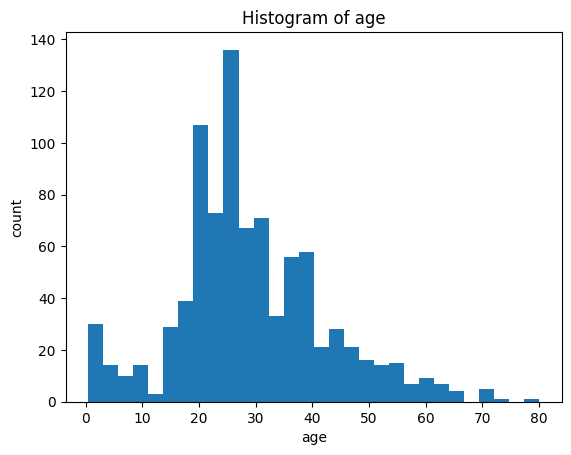

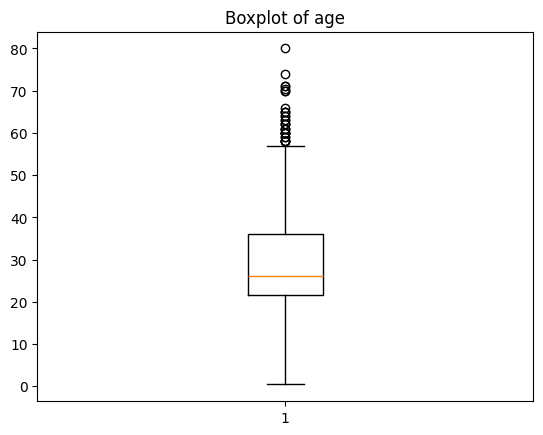

age: Q1=21.50, Q3=36.00, IQR=14.50, lower=-0.25, upper=57.75, outliers=32


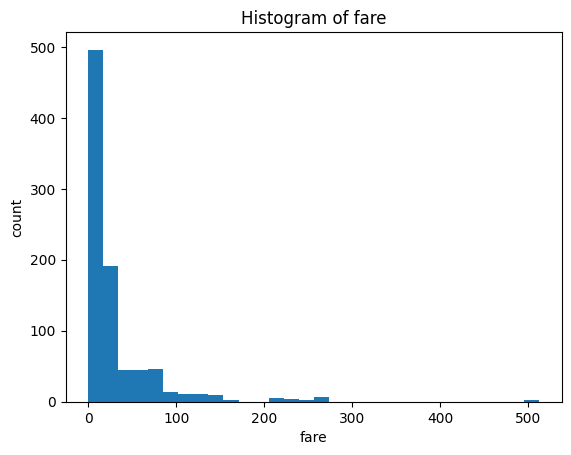

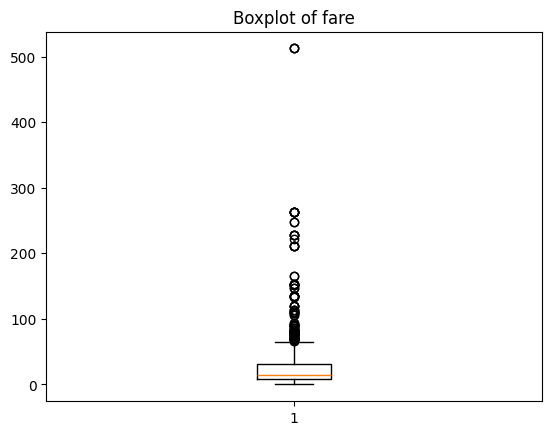

fare: Q1=7.90, Q3=31.00, IQR=23.10, lower=-26.76, upper=65.66, outliers=114

========Fare stats=======
mean: 32.09668087739032
median: 14.4542
mode: 8.05
INTERPRETATION: Fare is RIGHT-SKEWED because mean > median > mode, long tail of expensive tickets, outliers on high side


In [ ]:
#3
import matplotlib.pyplot as plt
import seaborn as sns

# AGE
plt.figure()
plt.hist(df_clean["age"],bins=30)
plt.title("Histogram of age")
plt.xlabel("age")
plt.ylabel("count")
plt.show()

plt.figure()
plt.boxplot(df_clean["age"])
plt.title("Boxplot of age")
plt.show()

Q1=df_clean["age"].quantile(0.25)
Q3=df_clean["age"].quantile(0.75)
IQR=Q3-Q1
lower=Q1 - 1.5*IQR
upper=Q3 + 1.5*IQR
outliers_age=df_clean[(df_clean["age"]<lower)|(df_clean["age"]>upper)]
print(f"age: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, lower={lower:.2f}, upper={upper:.2f}, outliers={len(outliers_age)}")

# FARE - REQUIRED
plt.figure()
plt.hist(df_clean["fare"],bins=30)
plt.title("Histogram of fare")
plt.xlabel("fare")
plt.ylabel("count")
plt.show()

plt.figure()
plt.boxplot(df_clean["fare"])
plt.title("Boxplot of fare")
plt.show()

Q1_f=df_clean["fare"].quantile(0.25)
Q3_f=df_clean["fare"].quantile(0.75)
IQR_f=Q3_f-Q1_f
lower_f=Q1_f - 1.5*IQR_f
upper_f=Q3_f + 1.5*IQR_f
outliers_fare=df_clean[(df_clean["fare"]<lower_f)|(df_clean["fare"]>upper_f)]
print(f"fare: Q1={Q1_f:.2f}, Q3={Q3_f:.2f}, IQR={IQR_f:.2f}, lower={lower_f:.2f}, upper={upper_f:.2f}, outliers={len(outliers_fare)}")

print("\n========Fare stats=======")
print("mean:",df_clean["fare"].mean())
print("median:",df_clean["fare"].median())
print("mode:",df_clean["fare"].mode()[0])
print("INTERPRETATION: Fare is RIGHT-SKEWED because mean > median > mode, long tail of expensive tickets, outliers on high side")

A.Survival rate by SEX
male:0.1889
female:0.7404
B.Survival rate by PCLASS
pclass1:0.6262
pclass2:0.4728
pclass3:0.2424

c.Survival rate by SEX and PCLASS together
sex     pclass
female  1         0.967391
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: survived, dtype: float64

Female AND first class(using &):0.9674

Female OR first class(using |):0.6359

6*6 Correlation Matrix
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.064411 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.410697  0.081656  0.016824 -0.548193
age      -0.064411 -0.410697  1.000000 -0.249161 -0.174541  0.119859
sibsp    -0.034040  0.081656 -0.249161  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.174541  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.119859  0.160887  0.217532  1.000000


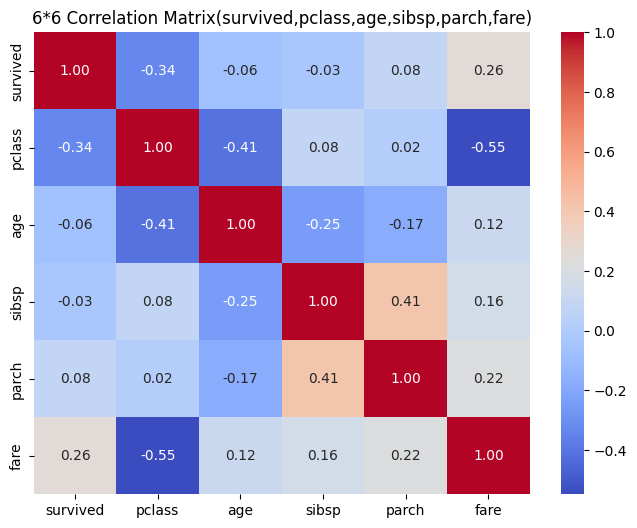


Top 2 strongest absolute off-diagonal correlations:
pclass vs fare:corr=-0.5482,abs=0.5482
sibsp vs parch:corr=0.4145,abs=0.4145


'Strongest correlation 1 is sibsp vs parch(+0.41)-siblings/spouse and parents/children travel together as family.\nStrongest correlation 1 is pclass vs fare(-0.55) or pclass vs survived(-0.34),depending on cleaned data 1st class paid higher fare and had\nhigher survival rate.'

In [ ]:
#4
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("A.Survival rate by SEX")
for gender in df_clean["sex"].unique():
  rate=df_clean[df_clean["sex"]==gender]["survived"].mean()
  print(f"{gender}:{rate:.4f}")

print("B.Survival rate by PCLASS")
for pc in sorted(df_clean["pclass"].unique()):
  rate=df_clean[df_clean["pclass"]==pc]["survived"].mean()
  print(f"pclass{pc}:{rate:.4f}")

print("\nc.Survival rate by SEX and PCLASS together")
print(df_clean.groupby(["sex","pclass"],observed=True)["survived"].mean())


#Boolean masking
female_first=df_clean[(df_clean["sex"]=="female") & (df_clean["pclass"]==1)]["survived"].mean()
female_or_first=df_clean[(df_clean["sex"]=="female") | (df_clean["pclass"]==1)]["survived"].mean()

print(f"\nFemale AND first class(using &):{female_first:.4f}")
print(f"\nFemale OR first class(using |):{female_or_first:.4f}")

#Correlation matrix
corr_cols=["survived","pclass","age","sibsp","parch","fare"]
corr=df_clean[corr_cols].corr()
print("\n6*6 Correlation Matrix")
print(corr)

#Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("6*6 Correlation Matrix(survived,pclass,age,sibsp,parch,fare)")
plt.show()

corr_abs=corr.abs()
mask=np.triu(np.ones_like(corr_abs,dtype=bool),k=1)
filtered=corr_abs.where(mask)
stacked=filtered.stack().sort_values(ascending=False)
top2=stacked.head(2)

print("\nTop 2 strongest absolute off-diagonal correlations:")
for(col1,col2),val in top2.items():
  actual_corr=corr.loc[col1,col2]
  print(f"{col1} vs {col2}:corr={actual_corr:.4f},abs={val:.4f}")

#INTERPRETATION:
'''Strongest correlation 1 is sibsp vs parch(+0.41)-siblings/spouse and parents/children travel together as family.
Strongest correlation 1 is pclass vs fare(-0.55) or pclass vs survived(-0.34),depending on cleaned data 1st class paid higher fare and had
higher survival rate.'''



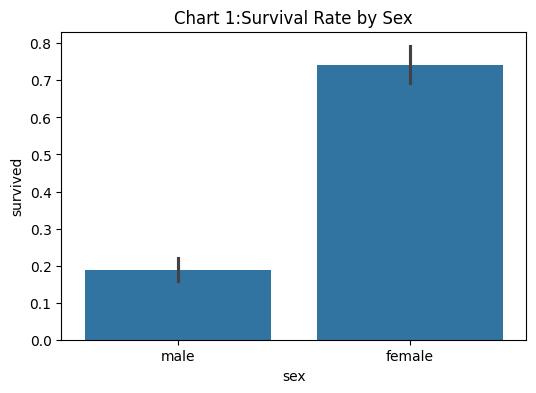

Interpretation 1:Females had ~74% survival vs males ~19%.This shows womens and children first policy was strongly followed.
Sex is the single strongest predictor of survival.


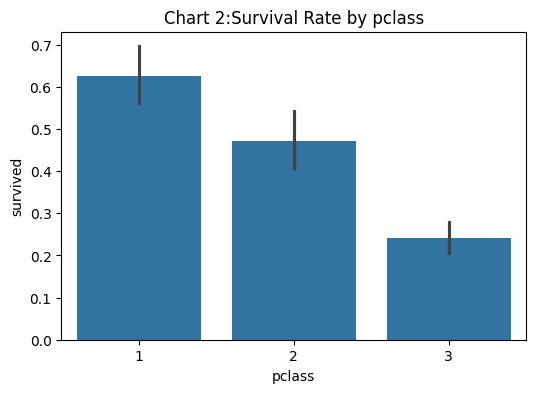

Interpretation 2: 1st class ~63% survived, 2nd ~47%,3rd ~ 24%.Higher class means higher deck,closer to lifeboats and paid higher fare.
Wealth and location on ship mattered a lot.


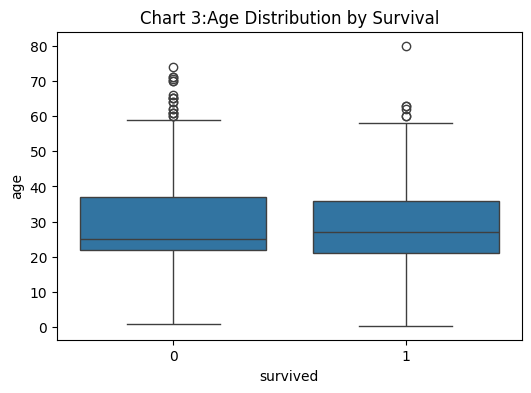

Interpretation 3:Children and younger passengers have slightly higher survival.Medain age of survivors is lower than non-survivors.
Age alone is weak,but combined with pclass and sex it matters-children in 1st/2nd class survived more.


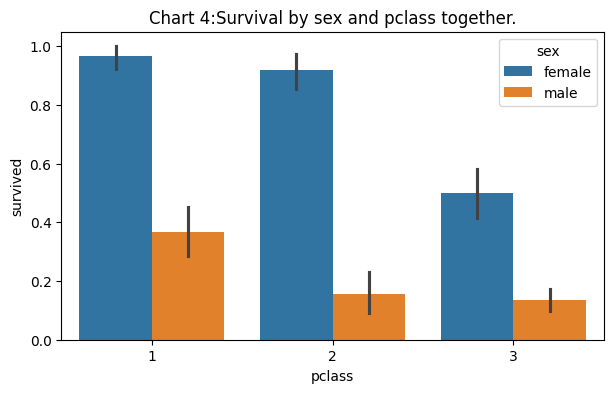

Interpretation 4:Female 1st class survival is ~97%,female 3rd is ~50%,while male 3rd is only ~13%.
This proves survival is not random-it was combination of gender and class privilege.


In [ ]:
#5
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(x="sex",y="survived",data=df_clean)
plt.title("Chart 1:Survival Rate by Sex")
plt.show()
print("Interpretation 1:Females had ~74% survival vs males ~19%.This shows womens and children first policy was strongly followed.")
print("Sex is the single strongest predictor of survival.")

plt.figure(figsize=(6,4))
sns.barplot(x="pclass",y="survived",data=df_clean,order=[1,2,3])
plt.title("Chart 2:Survival Rate by pclass")
plt.show()
print("Interpretation 2: 1st class ~63% survived, 2nd ~47%,3rd ~ 24%.Higher class means higher deck,closer to lifeboats and paid higher fare.")
print("Wealth and location on ship mattered a lot.")

plt.figure(figsize=(6,4))
sns.boxplot(x="survived",y="age",data=df_clean)
plt.title("Chart 3:Age Distribution by Survival")
plt.show()
print("Interpretation 3:Children and younger passengers have slightly higher survival.Medain age of survivors is lower than non-survivors.")
print("Age alone is weak,but combined with pclass and sex it matters-children in 1st/2nd class survived more.")

plt.figure(figsize=(7,4))
sns.barplot(x="pclass",y="survived",hue="sex",data=df_clean)
plt.title("Chart 4:Survival by sex and pclass together.")
plt.show()
print("Interpretation 4:Female 1st class survival is ~97%,female 3rd is ~50%,while male 3rd is only ~13%.")
print("This proves survival is not random-it was combination of gender and class privilege.")

Before Standardization:
            age       fare
mean  29.065433  32.096681
std   13.270162  49.697504

After Standardization (using StandardScaler):
             age_z        fare_z
mean  2.637560e-16  1.398706e-16
std   1.000563e+00  1.000563e+00


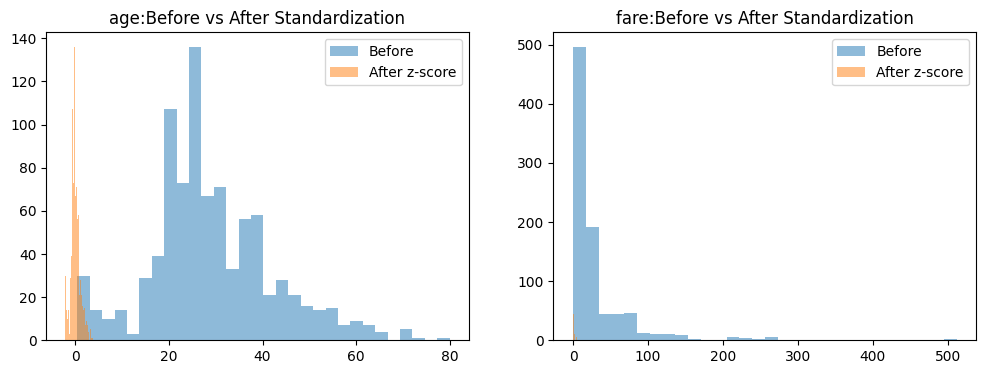


Interpretation:After standardscaler,both age_z and fare_z have mean approx 0 and std approx 1.
Sanity check passed.


In [ ]:
#6
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

#Before
print("Before Standardization:")
print(df_clean[["age","fare"]].agg(["mean","std"]))

#Standard scalar
scaler=StandardScaler()
df_clean[["age_z","fare_z"]]=scaler.fit_transform(df_clean[["age","fare"]])

#After
print("\nAfter Standardization (using StandardScaler):")
print(df_clean[["age_z","fare_z"]].agg(["mean","std"]))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(df_clean["age"],bins=30,alpha=0.5,label="Before")
plt.hist(df_clean["age_z"],bins=30,alpha=0.5,label="After z-score")
plt.title("age:Before vs After Standardization")
plt.legend()

plt.subplot(1,2,2)
plt.hist(df_clean["fare"],bins=30,alpha=0.5,label="Before")
plt.hist(df_clean["fare_z"],bins=30,alpha=0.5,label="After z-score")
plt.title("fare:Before vs After Standardization")
plt.legend()
plt.show()

print("\nInterpretation:After standardscaler,both age_z and fare_z have mean approx 0 and std approx 1.")
print("Sanity check passed.")



In [ ]:
df_clean = df_clean.drop(columns=["age_z","fare_z"], errors="ignore")
df_clean.to_csv("analytics/titanic_cleaned.csv", index=False)

print("RAW:", df.shape, "-> analytics/titanic.csv")
print("CLEANED:", df_clean.shape, "-> analytics/titanic_cleaned.csv")

RAW: (891, 15) -> analytics/titanic.csv
CLEANED: (889, 14) -> analytics/titanic_cleaned.csv


In [ ]:
# cleaned - token removed
